# Analisi XGBoost — Classificazione eventi e preservazione spettro Ep

**Flusso del notebook:**
1. Caricamento dati e preprocessing (StandardScaler)
2. Ottimizzazione iperparametri (Optuna) con obiettivo combinato AUC + preservazione spettro Ep
3. Cross-validation manuale con best params → curve di loss per fold, stima n_estimators ottimale
4. Training finale su tutto X_train con n_estimators fisso (senza early stopping)
5. Test su X_test e visualizzazioni complete
6. Sottrazione del background tramite shift temporale (coppie accidentali)

## 1 — Import e configurazione

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import json

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

# Moduli custom
from create_datasets import dataset_creator
from Optimization import optimize_with_spectra, summarize_study
from XGB_model import build_and_train_model
from visualization import (
    plot_training_curves,
    plot_feature_importance,
    plot_score_distribution,
    plot_roc_curve,
    plot_pr_curve,
    plot_threshold_scan,
    plot_confusion_matrix,
    plot_energy_spectra,
    plot_efficiency,
    plot_score_vs_variable,
)

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    from tqdm.std import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except ImportError:
    pass

%matplotlib inline


## 2 — Path dei dati

In [2]:
PATH_EVENTS     = "/Users/nicol/OneDrive/Desktop/LCP-modB/events_tr.parquet"
PATH_BACKGROUND = "/Users/nicol/OneDrive/Desktop/LCP-modB/background_tr.parquet"
FIGURES_DIR = "figs"
TARGET     = "is_event"
ENERGY_COL = "Ep"
DROP_COLS  = [TARGET, ENERGY_COL, 'E_sum', 'E_diff', 'theta_p', 'theta_d', 'p_time', 'd_time', 'rp', 'rd', 'E_div', 'E_asym', 'zp', 'zd']


In [15]:
from pathlib import Path

FIGURES_DIR = Path("figs")


## 3 — Caricamento dati

In [3]:
X_train_full, X_test, y_train_full, y_test, Ep_train_full, Ep_test = dataset_creator(
    PATH_EVENTS,
    PATH_BACKGROUND,
    target=TARGET,
    drop=DROP_COLS,
    analysis_cols=[ENERGY_COL],
)

Ep_train_full = Ep_train_full[ENERGY_COL].values
Ep_test       = Ep_test[ENERGY_COL].values

print(f"Training set : {X_train_full.shape[0]:>8,} eventi — {X_train_full.shape[1]} feature")
print(f"Test set     : {X_test.shape[0]:>8,} eventi")
print(f"Segnale (train): {y_train_full.mean():.3f}   Segnale (test): {y_test.mean():.3f}")
print(f"\nFeature: {list(X_train_full.columns)}")


Training set :  159,912 eventi — 15 feature
Test set     :   39,978 eventi
Segnale (train): 0.500   Segnale (test): 0.500

Feature: ['Ed', 'delta_x', 'delta_y', 'delta_z', 'edist', 'dist_wall_p', 'dist_wall_d', 'dist_wall_h_p', 'dist_wall_h_d', 'edist_over_r', 'delta_r', 'delta_theta', 'delta_t', 'diffusion', 'ds2']


## 4 — Split train/val per ottimizzazione e StandardScaler

Questo split interno serve **solo** per l'ottimizzazione Optuna. Il training finale userà tutto X_train_full.

In [4]:
# Split interno solo per ottimizzazione
X_train_opt, X_val_opt, y_train_opt, y_val_opt, Ep_train_opt, Ep_val_opt = train_test_split(
    X_train_full, y_train_full, Ep_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

# StandardScaler — fit su tutto il training set
scaler = StandardScaler()
scaler.fit(X_train_full)

X_train_full_sc = pd.DataFrame(scaler.transform(X_train_full), columns=X_train_full.columns)
X_train_opt_sc  = pd.DataFrame(scaler.transform(X_train_opt),  columns=X_train_opt.columns)
X_val_opt_sc    = pd.DataFrame(scaler.transform(X_val_opt),    columns=X_val_opt.columns)
X_test_sc       = pd.DataFrame(scaler.transform(X_test),       columns=X_test.columns)

print(f"Train (ottimizzazione) : {X_train_opt_sc.shape[0]:>7,}")
print(f"Val   (ottimizzazione) : {X_val_opt_sc.shape[0]:>7,}")
print(f"Train full (CV + final): {X_train_full_sc.shape[0]:>7,}")
print(f"Test                   : {X_test_sc.shape[0]:>7,}")


Train (ottimizzazione) : 127,929
Val   (ottimizzazione) :  31,983
Train full (CV + final): 159,912
Test                   :  39,978


## 5 — Ottimizzazione iperparametri (Optuna)

Funzione obiettivo combinata: AUC − Wasserstein − χ² sullo spettro Ep.

In [5]:
best_params, study = optimize_with_spectra(
    X_train=X_train_opt_sc,
    y_train=y_train_opt,
    X_val=X_val_opt_sc,
    y_val=y_val_opt,
    E_val=Ep_val_opt,
    E_truth_val=Ep_val_opt[y_val_opt.values == 1],
    selection_threshold=0.5,
    lambda_auc=1.0,
    lambda_wass=1.0,
    lambda_chi2=0.5,
    n_trials=80,
    sampler_seed=42,
    verbose=True,
)



 Trial │  Objective │      AUC │  Wasserstein │   χ² low-E │   N sel │ Status
───────────────────────────────────────────────────────────────────────────
     0 │  -0.500000 │ 0.995609 │       0.0499 │     0.0066 │   16068 │ ★ BEST
     1 │  -0.676530 │ 0.994516 │       0.0571 │     0.0070 │   16133 │ 
     2 │  -0.514724 │ 0.995515 │       0.0517 │     0.0063 │   16101 │ 
     3 │  -0.555620 │ 0.995098 │       0.0543 │     0.0062 │   16118 │ 
     4 │  -0.486859 │ 0.995467 │       0.0500 │     0.0064 │   16067 │ ★ BEST
     5 │  -1.409235 │ 0.991711 │       0.0766 │     0.0115 │   16185 │ 
     6 │  -0.442444 │ 0.995715 │       0.0502 │     0.0058 │   16069 │ ★ BEST
     7 │  -2.256204 │ 0.988937 │       0.0953 │     0.0177 │   16359 │ 
     8 │  -0.816135 │ 0.994014 │       0.0618 │     0.0076 │   16143 │ 
     9 │  -0.490097 │ 0.995531 │       0.0510 │     0.0062 │   16109 │ 
    10 │  -0.442833 │ 0.995750 │       0.0504 │     0.0057 │   16080 │ 
    11 │  -0.435597 │ 0.995723 │   

In [6]:
summarize_study(study, top_n=10)



  STUDIO: 80 trial completati
 Rank │  Trial │  Objective │      AUC │  Wasserstein │   χ² low-E │   N sel
────────────────────────────────────────────────────────────────────────────────
    1 │     62 │  -0.351843 │ 0.995601 │       0.0492 │     0.0049 │   16062
    2 │     48 │  -0.374977 │ 0.995690 │       0.0503 │     0.0049 │   16068
    3 │     53 │  -0.375222 │ 0.995707 │       0.0493 │     0.0051 │   16064
    4 │     21 │  -0.381600 │ 0.995745 │       0.0492 │     0.0052 │   16080
    5 │     18 │  -0.384384 │ 0.995724 │       0.0493 │     0.0053 │   16086
    6 │     27 │  -0.386234 │ 0.995725 │       0.0497 │     0.0052 │   16080
    7 │     31 │  -0.386535 │ 0.995703 │       0.0495 │     0.0052 │   16073
    8 │     63 │  -0.389056 │ 0.995644 │       0.0483 │     0.0056 │   16067
    9 │     75 │  -0.390057 │ 0.995758 │       0.0494 │     0.0053 │   16071
   10 │     55 │  -0.399780 │ 0.995641 │       0.0507 │     0.0051 │   16086

  Best hyperparameters (trial #62)
─────

## 6 — Cross-Validation con best params

CV manuale 5-fold su X_train_full per:
- Verificare l'andamento della loss (overfitting check)
- Determinare il **numero ottimale di alberi** (media dei best_iteration) da usare nel training finale

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_params = {k: v for k, v in best_params.items()}
cv_params.update(dict(
    tree_method="hist",
    eval_metric="logloss",
    early_stopping_rounds=15,
    random_state=42,
))

fold_aucs = []
fold_best_iters = []
fold_evals = []

for i, (train_idx, val_idx) in enumerate(cv.split(X_train_full_sc, y_train_full)):
    X_tr = X_train_full_sc.iloc[train_idx]
    X_vl = X_train_full_sc.iloc[val_idx]
    y_tr = y_train_full.iloc[train_idx]
    y_vl = y_train_full.iloc[val_idx]

    model_cv = xgb.XGBClassifier(**cv_params)
    model_cv.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_vl, y_vl)],
        verbose=False,
    )

    fold_best_iters.append(model_cv.best_iteration)
    fold_evals.append(model_cv.evals_result())

    auc_vl = roc_auc_score(y_vl, model_cv.predict_proba(X_vl)[:, 1])
    fold_aucs.append(auc_vl)

    print(f"  Fold {i+1}: AUC = {auc_vl:.4f}  |  best_iteration = {model_cv.best_iteration}")

n_est_optimal = int(np.mean(fold_best_iters))

print(f"\nBest iterations per fold : {fold_best_iters}")
print(f"N estimators ottimale    : {n_est_optimal}")
print(f"AUC media                : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")


  Fold 1: AUC = 0.9955  |  best_iteration = 80
  Fold 2: AUC = 0.9955  |  best_iteration = 55
  Fold 3: AUC = 0.9957  |  best_iteration = 52
  Fold 4: AUC = 0.9956  |  best_iteration = 60
  Fold 5: AUC = 0.9953  |  best_iteration = 49

Best iterations per fold : [80, 55, 52, 60, 49]
N estimators ottimale    : 59
AUC media                : 0.9955 ± 0.0001


### Curve di loss per ogni fold

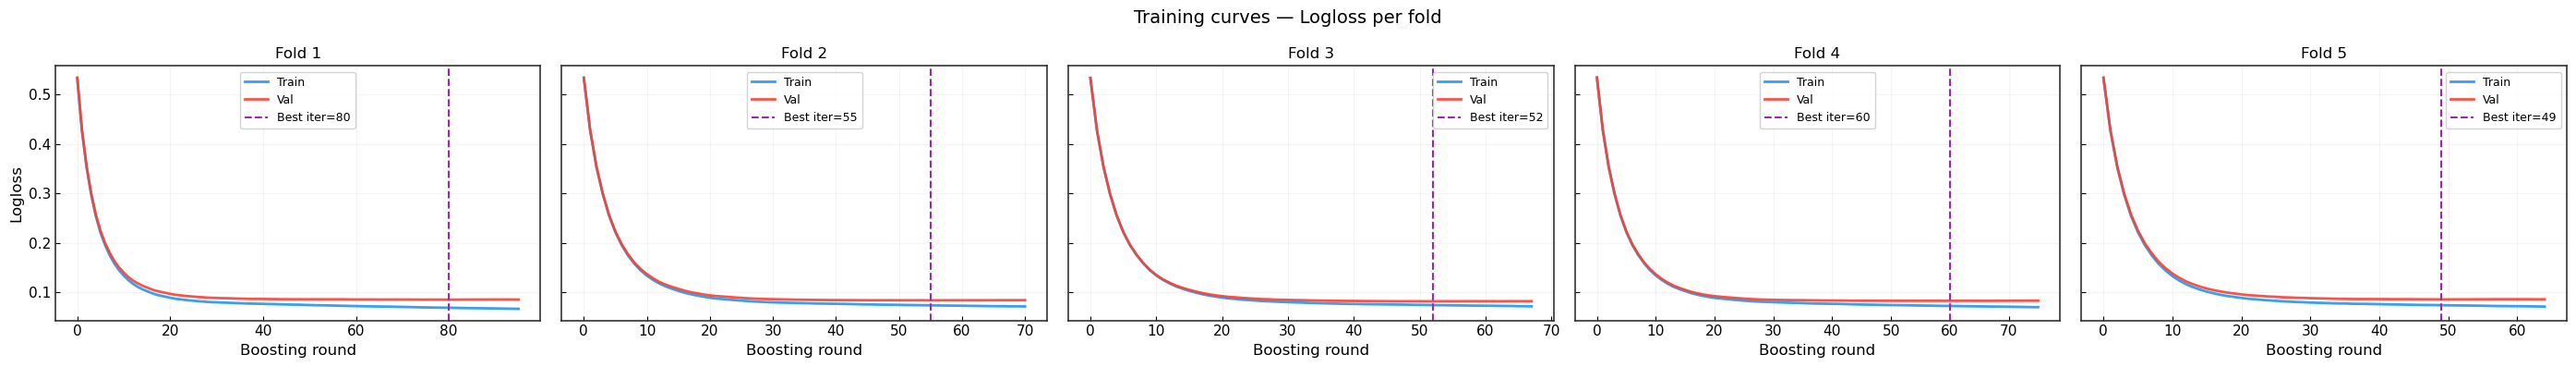

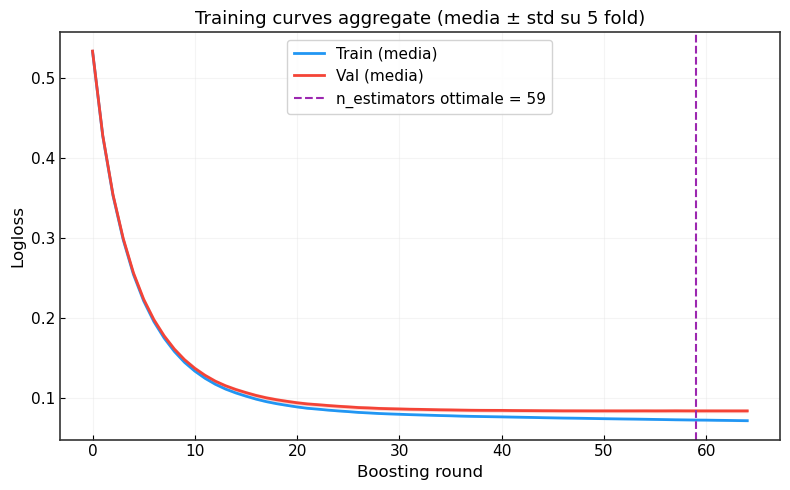

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(28, 4), sharey=True)
fig.suptitle("Training curves — Logloss per fold", fontsize=14)

for i, (evals, best_iter) in enumerate(zip(fold_evals, fold_best_iters)):
    ax = axes[i]
    ax.plot(evals["validation_0"]["logloss"], label="Train",  color="#2196F3", alpha=0.9)
    ax.plot(evals["validation_1"]["logloss"], label="Val",    color="#F44336", alpha=0.9)
    ax.axvline(best_iter, color="#9C27B0", linestyle="--", linewidth=1.5,
               label=f"Best iter={best_iter}")
    ax.set_title(f"Fold {i+1}", fontsize=12)
    ax.set_xlabel("Boosting round")
    if i == 0:
        ax.set_ylabel("Logloss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot aggregato: media ± std delle curve di validation
fig, ax = plt.subplots(figsize=(8, 5))
max_len = min(len(e["validation_1"]["logloss"]) for e in fold_evals)
val_curves = np.array([e["validation_1"]["logloss"][:max_len] for e in fold_evals])
train_curves = np.array([e["validation_0"]["logloss"][:max_len] for e in fold_evals])

rounds = np.arange(max_len)
ax.plot(rounds, train_curves.mean(axis=0), color="#2196F3", label="Train (media)")
ax.fill_between(rounds,
                train_curves.mean(0) - train_curves.std(0),
                train_curves.mean(0) + train_curves.std(0),
                color="#2196F3", alpha=0.15)
ax.plot(rounds, val_curves.mean(axis=0), color="#F44336", label="Val (media)")
ax.fill_between(rounds,
                val_curves.mean(0) - val_curves.std(0),
                val_curves.mean(0) + val_curves.std(0),
                color="#F44336", alpha=0.15)
ax.axvline(n_est_optimal, color="#9C27B0", linestyle="--", linewidth=1.5,
           label=f"n_estimators ottimale = {n_est_optimal}")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Logloss")
ax.set_title("Training curves aggregate (media ± std su 5 fold)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7 — Training finale su tutto X_train

Il modello viene allenato su **tutto** X_train_full con `n_estimators` fisso (ricavato dalla CV), senza early stopping. X_test viene passato come eval_set solo per monitorare la loss, non influenza il training.

In [9]:
# Parametri finali: best_params + n_estimators dalla CV
final_params = {k: v for k, v in best_params.items() if k != "n_estimators"}

model = build_and_train_model(
    X_train=X_train_full_sc,
    y_train=y_train_full,
    X_val=X_test_sc,
    y_val=y_test,
    n_estimators=n_est_optimal,
    early_stopping_rounds=n_est_optimal,   # disabilitato di fatto
    **final_params,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    verbose=10,
)

print(f"\nTraining completato: {n_est_optimal} alberi")


[0]	validation_0-logloss:0.53389	validation_1-logloss:0.53441
[10]	validation_0-logloss:0.13425	validation_1-logloss:0.13891
[20]	validation_0-logloss:0.08929	validation_1-logloss:0.09675
[30]	validation_0-logloss:0.08056	validation_1-logloss:0.08987
[40]	validation_0-logloss:0.07707	validation_1-logloss:0.08819
[50]	validation_0-logloss:0.07537	validation_1-logloss:0.08777
[58]	validation_0-logloss:0.07412	validation_1-logloss:0.08784

Training completato: 59 alberi


In [28]:
dump_df = model.get_booster().trees_to_dataframe()

# 4. Calcoliamo i parametri reali
# I nodi foglia hanno Feature == 'Leaf'
num_foglie_reali = dump_df[dump_df['Feature'] == 'Leaf'].shape[0]

# I nodi di split sono tutti gli altri
num_nodi_split = dump_df[dump_df['Feature'] != 'Leaf'].shape[0]

# Ogni nodo di split memorizza la feature e la soglia (2 parametri), ogni foglia il valore di output
parametri_totali = (num_nodi_split * 2) + num_foglie_reali

# 5. Stampa dei risultati
print(f"--- RISULTATI REALI (Dopo il fit) ---")
print(f"Numero totale di alberi creati: {dump_df['Tree'].nunique()}")
print(f"Numero totale di nodi foglia: {num_foglie_reali}")
print(f"Numero totale di nodi di split: {num_nodi_split}")
print(f"Stima dei parametri numerici salvati: {parametri_totali}")

--- RISULTATI REALI (Dopo il fit) ---
Numero totale di alberi creati: 59
Numero totale di nodi foglia: 2168
Numero totale di nodi di split: 2109
Stima dei parametri numerici salvati: 6386


## 8 — Valutazione sul test set

In [10]:
scores_test = model.predict_proba(X_test_sc)[:, 1]
auc_test = roc_auc_score(y_test, scores_test)
print(f"AUC sul test set: {auc_test:.4f}")


AUC sul test set: 0.9951


In [11]:
model.save_model("xgb_ibd_model.json")
joblib.dump(scaler, "scaler.pkl")
with open("xgb_meta.json", "w") as f:
    json.dump({"feature_cols": list(X_train_full.columns)}, f)

## 9 — Visualizzazioni

### 9.1 — Curve di training del modello finale

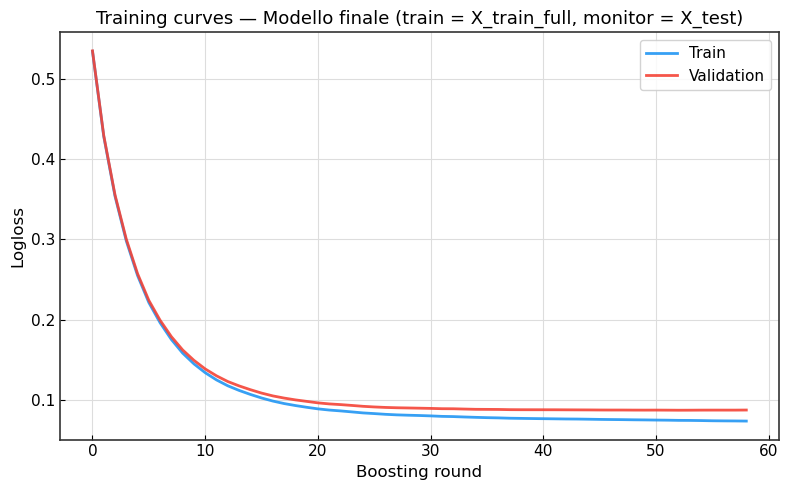

In [12]:
evals_final = model.evals_result()
plot_training_curves(
    evals_final,
    metric="logloss",
    title="Training curves — Modello finale (train = X_train_full, monitor = X_test)",
)
plt.show()


### 9.2 — Feature importance

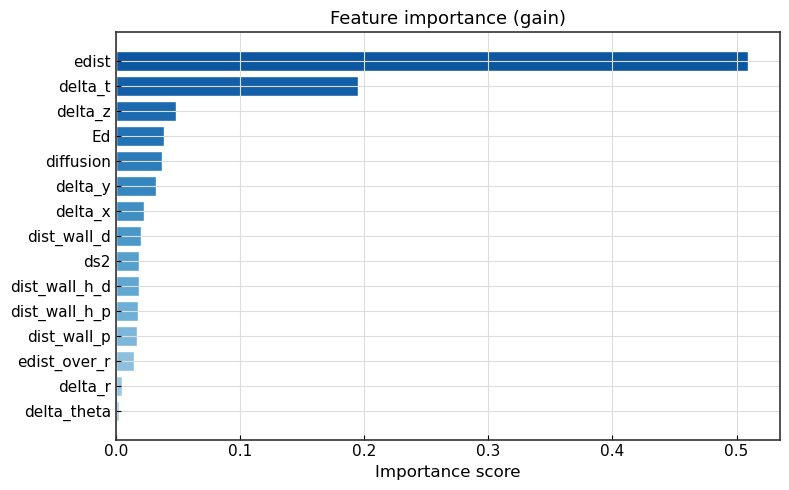

In [16]:
plot_feature_importance(
    model.feature_importances_,
    X_train_full_sc.columns,
    top_n=len(X_train_full_sc.columns),
    title="Feature importance (gain)",
)
plt.savefig(FIGURES_DIR / "feature_imp.png", dpi=300, bbox_inches="tight")

plt.show()


### 9.3 — Distribuzione dello score

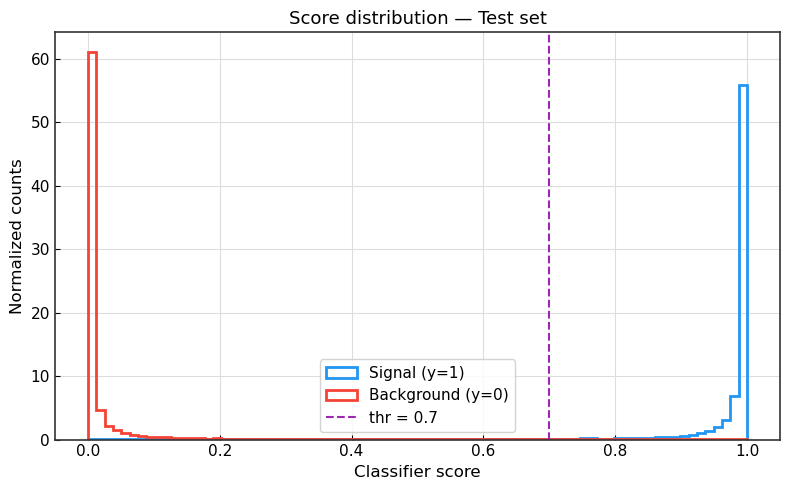

In [17]:
plot_score_distribution(
    scores_test,
    y_test.values,
    thresholds=[0.7],
    threshold_labels=["thr = 0.7"],
    title="Score distribution — Test set",
)
plt.savefig(FIGURES_DIR / "score_distr.png", dpi=300, bbox_inches="tight")

plt.show()


### 9.4 — Curva ROC

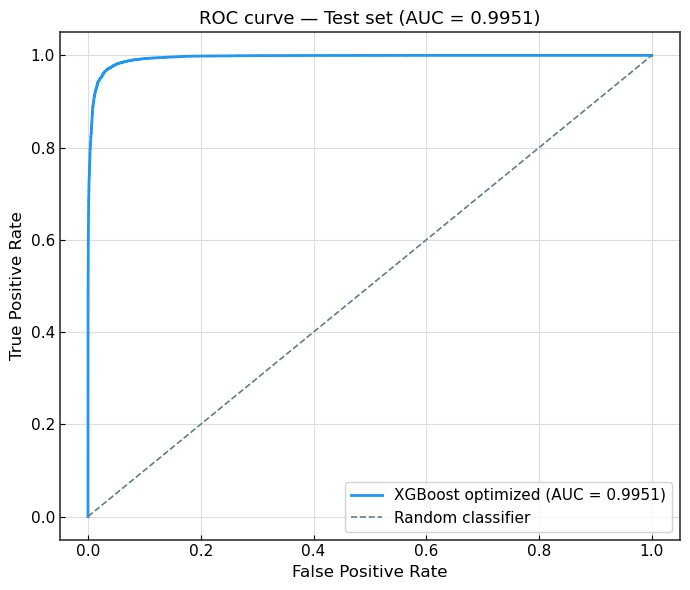

In [18]:
plot_roc_curve(
    y_test.values,
    scores_test,
    label="XGBoost optimized",
    title=f"ROC curve — Test set (AUC = {auc_test:.4f})",
)
plt.savefig(FIGURES_DIR / "roc.png", dpi=300, bbox_inches="tight")

plt.show()


### 9.5 — Curva Precision-Recall

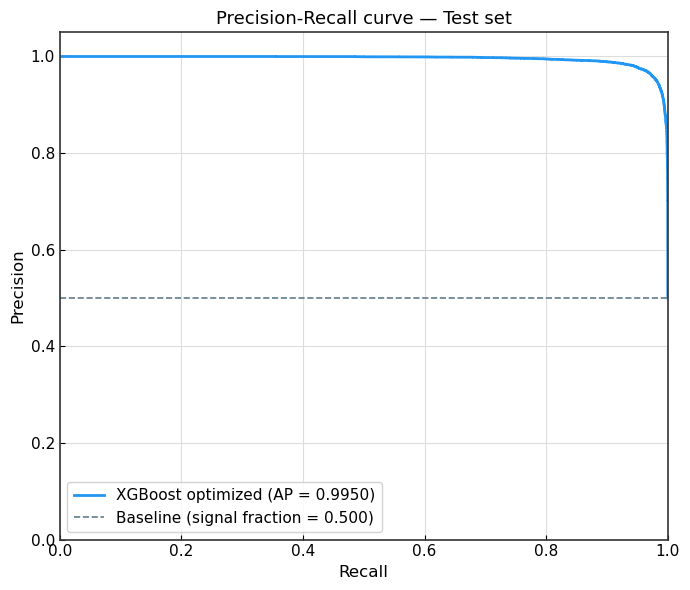

In [19]:
plot_pr_curve(
    y_test.values,
    scores_test,
    label="XGBoost optimized",
    title="Precision-Recall curve — Test set",
)
plt.show()


### 9.6 — Threshold scan


Soglia ottimale (max F1): 0.4874


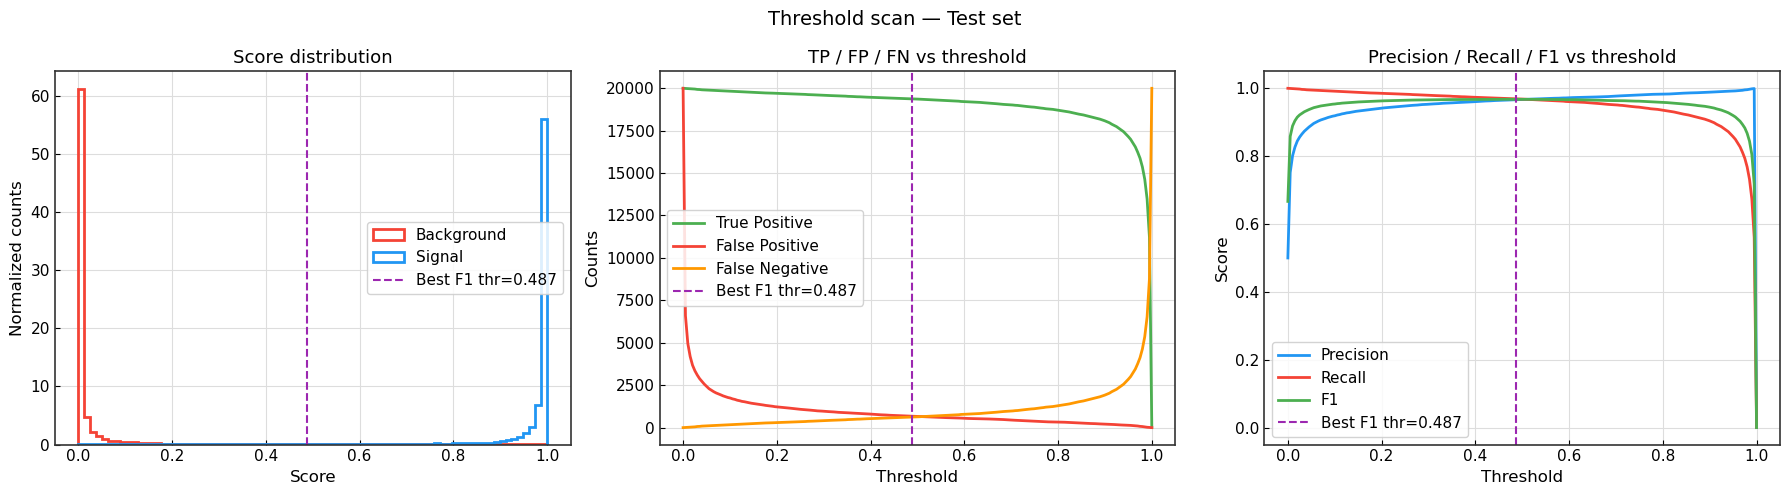

In [20]:
_, best_thr = plot_threshold_scan(
    y_test.values,
    scores_test,
    title="Threshold scan — Test set",
)
print(f"\nSoglia ottimale (max F1): {best_thr:.4f}")
plt.show()


### 9.7 — Matrice di confusione

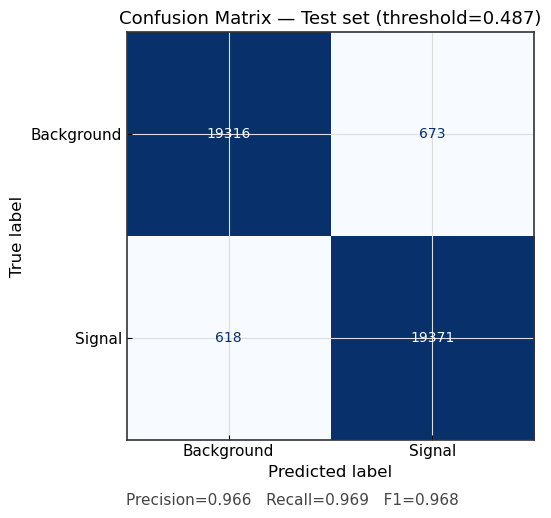


              precision    recall  f1-score   support

  Background       0.97      0.97      0.97     19989
      Signal       0.97      0.97      0.97     19989

    accuracy                           0.97     39978
   macro avg       0.97      0.97      0.97     39978
weighted avg       0.97      0.97      0.97     39978



In [21]:
y_pred_test = (scores_test > best_thr).astype(int)

plot_confusion_matrix(
    y_test.values,
    y_pred_test,
    threshold=best_thr,
    title="Confusion Matrix — Test set",
)
plt.show()

print("\n" + classification_report(
    y_test, y_pred_test,
    target_names=["Background", "Signal"],
))


### 9.8 — Confronto spettri Ep (ground truth vs selezionati)

Plot fondamentale: lo spettro degli eventi predetti deve sovrapporsi a quello del segnale vero senza distorsioni.

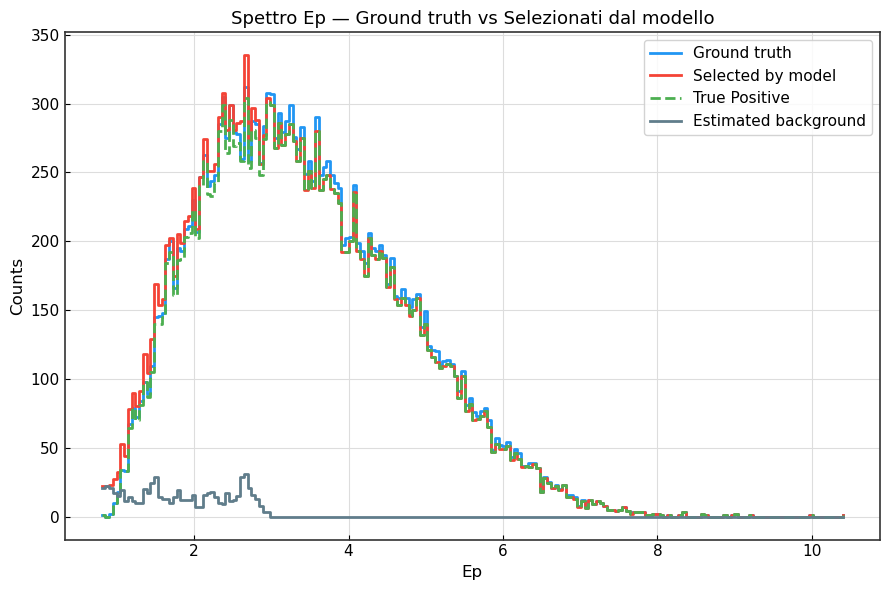

In [22]:
Ep_true_signal = Ep_test[y_test.values == 1]

selected_mask = scores_test > best_thr
Ep_selected   = Ep_test[selected_mask]

tp_mask = selected_mask & (y_test.values == 1)
Ep_tp   = Ep_test[tp_mask]

fp_mask = selected_mask & (y_test.values == 0)
Ep_fp   = Ep_test[fp_mask]

plot_energy_spectra(
    E_true=Ep_true_signal,
    E_selected=Ep_selected,
    E_tp=Ep_tp,
    E_background = Ep_fp,
    bins=200,
    log_y=False,
    x_label="Ep",
    title="Spettro Ep — Ground truth vs Selezionati dal modello",
)
plt.show()


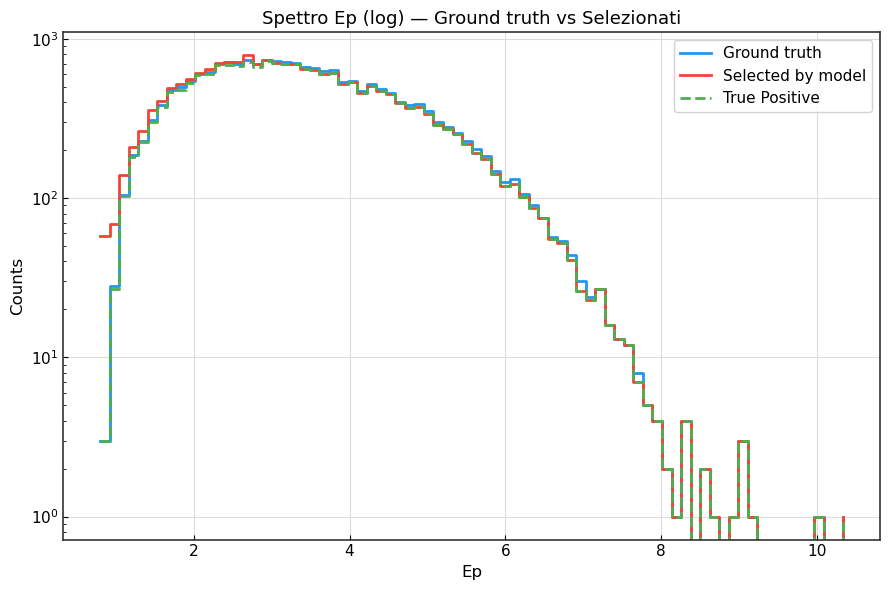

In [23]:
plot_energy_spectra(
    E_true=Ep_true_signal,
    E_selected=Ep_selected,
    E_tp=Ep_tp,
    bins=80,
    log_y=True,
    x_label="Ep",
    title="Spettro Ep (log) — Ground truth vs Selezionati",
)
plt.show()


### 9.9 — Spettro Ep normalizzato (overlay)

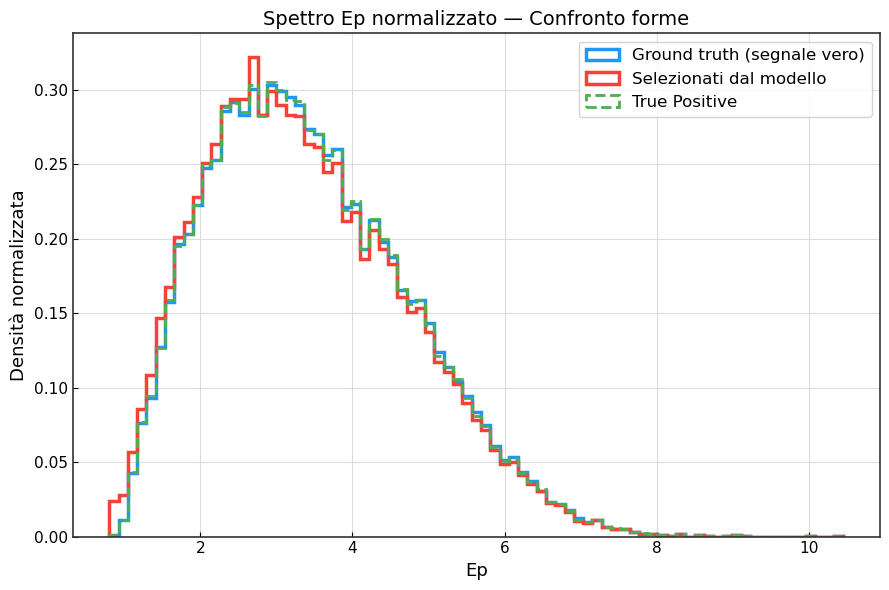

Wasserstein distance (truth vs selected): 0.058815
Wasserstein distance (truth vs TP)      : 0.005000


In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

bins_ep = np.linspace(
    min(Ep_true_signal.min(), Ep_selected.min()),
    max(Ep_true_signal.max(), Ep_selected.max()),
    80,
)

ax.hist(Ep_true_signal, bins=bins_ep, histtype="step", linewidth=2.5,
        density=True, color="#2196F3", label="Ground truth (segnale vero)")
ax.hist(Ep_selected, bins=bins_ep, histtype="step", linewidth=2.5,
        density=True, color="#F44336", label="Selezionati dal modello")
ax.hist(Ep_tp, bins=bins_ep, histtype="step", linewidth=2, linestyle="--",
        density=True, color="#4CAF50", label="True Positive")

ax.set_xlabel("Ep", fontsize=13)
ax.set_ylabel("Densità normalizzata", fontsize=13)
ax.set_title("Spettro Ep normalizzato — Confronto forme", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

from scipy.stats import wasserstein_distance
wd = wasserstein_distance(Ep_true_signal, Ep_selected)
print(f"Wasserstein distance (truth vs selected): {wd:.6f}")
wd_tp = wasserstein_distance(Ep_true_signal, Ep_tp)
print(f"Wasserstein distance (truth vs TP)      : {wd_tp:.6f}")


### 9.10 — Rapporto spettri (selected / truth)

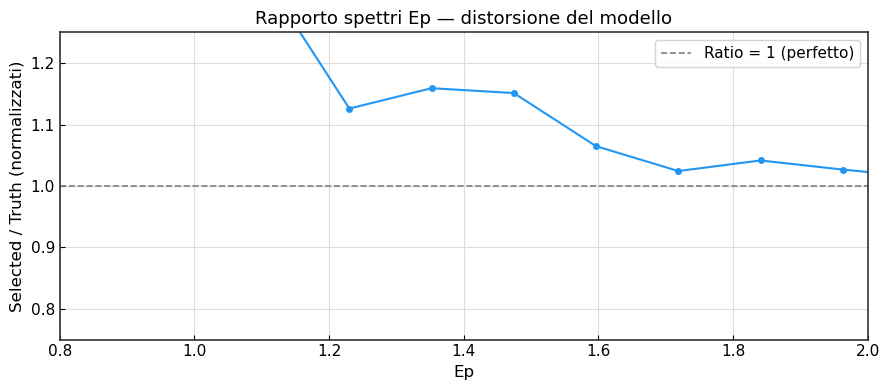

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

h_truth, bin_edges = np.histogram(Ep_true_signal, bins=bins_ep)
h_sel, _           = np.histogram(Ep_selected,    bins=bins_ep)

h_truth_norm = h_truth / (h_truth.sum() + 1e-12)
h_sel_norm   = h_sel   / (h_sel.sum()   + 1e-12)

ratio = h_sel_norm / (h_truth_norm + 1e-12)
ratio[h_truth < 5] = np.nan

centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

ax.plot(centers, ratio, marker="o", markersize=4, color="#2196F3", linewidth=1.5)
ax.axhline(1.0, linestyle="--", color="grey", linewidth=1.2, label="Ratio = 1 (perfetto)")
ax.set_xlabel("Ep", fontsize=12)
ax.set_ylabel("Selected / Truth (normalizzati)", fontsize=12)
ax.set_title("Rapporto spettri Ep — distorsione del modello", fontsize=13)
#ax.set_ylim([0, 2])
ax.set_ylim([0.75, 1.25])
ax.set_xlim([0.8,2])
ax.legend()
plt.tight_layout()
plt.show()


### 9.11 — Efficienza di selezione vs Ep

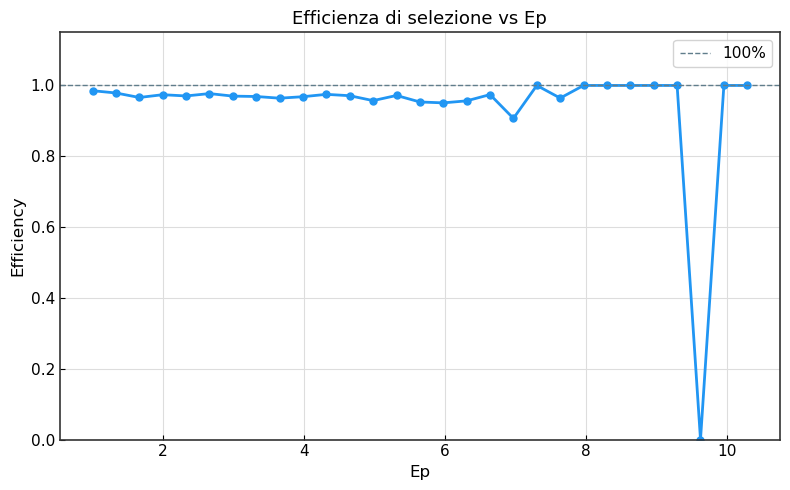

In [26]:
plot_efficiency(
    E_before=Ep_true_signal,
    E_after=Ep_tp,
    bins=30,
    log_x=False,
    x_label="Ep",
    title="Efficienza di selezione vs Ep",
)
plt.show()


### 9.12 — Correlazione residua: Score vs Ep

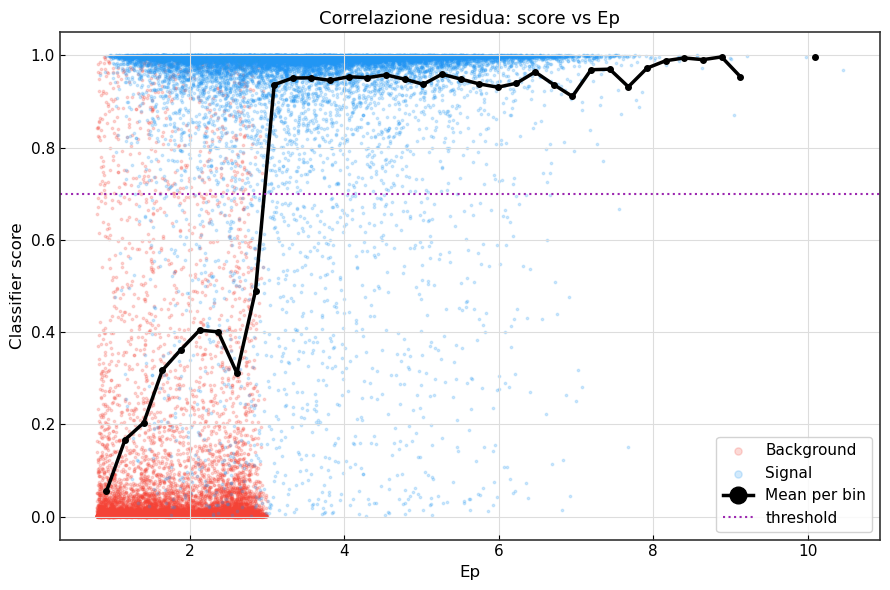

In [27]:
plot_score_vs_variable(
    variable=Ep_test,
    scores=scores_test,
    y_true=y_test.values,
    threshold=0.7,
    var_label="Ep",
    title="Correlazione residua: score vs Ep",
)
plt.savefig(FIGURES_DIR / "score_ep.png", dpi=300, bbox_inches="tight")

plt.show()


## 10 — Sottrazione del background tramite shift temporale

Seguendo l'approccio di `workflow_ordinato.ipynb`, la contaminazione di
background accidentale del campione selezionato viene stimata in modo
data-driven: eventi lontani nel tempo reale vengono accoppiati tra loro
(così ogni correlazione temporale genuina viene distrutta) e la loro
separazione temporale viene riportata dentro la finestra di coincidenza
fisica tramite un grande **shift temporale** negativo.

Punto chiave: le coppie shiftate vengono costruite con **lo stesso set di
feature e le stesse trasformazioni** usate per il training (quelle create
in `dataset_setup.ipynb`), poi le colonne inutilizzate (`DROP_COLS`)
vengono rimosse, così il modello XGBoost addestrato può essere applicato
direttamente.

La generazione delle coppie è gestita da `background_pairs.py`, che è
indipendente dal modello (lo stesso file usato per la rete neurale).

**Input richiesto:** la tabella raw degli eventi singoli `events.parquet`
(a livello di evento, *prima* della costruzione delle coppie).

### 10.1 — Caricamento dati raw e geometria del detector

In [29]:
from build_pairs import (
    generate_background_pairs,
    estimate_background_spectrum,
    compute_detector_geometry,
)

# =====================================================================
# Tabella raw degli eventi singoli (a livello di evento, prima delle coppie).
# È lo stesso file usato come input da dataset_setup.ipynb.
# =====================================================================
PATH_RAW_EVENTS = "/Users/francesco/anaconda_projects/LCP-neutrino/data/training/events.parquet"

raw_events = pd.read_parquet(PATH_RAW_EVENTS)

# Colonne nell'ordine atteso [time, energy, x, y, z] e stream ordinato per tempo
# (richiesto dal kernel di pairing).
raw_events = raw_events[["time", "energy", "x", "y", "z"]].sort_values("time").reset_index(drop=True)

# Geometria del detector (R_DET, Z_MAX) — calcolata come in dataset_setup
R_DET, Z_MAX = compute_detector_geometry(raw_events)

print(f"Eventi raw: {len(raw_events):,}")
print(f"R_DET = {R_DET:.4f}   Z_MAX = {Z_MAX:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/francesco/anaconda_projects/LCP-neutrino/data/training/events.parquet'

### 10.2 — Generazione coppie shiftate e applicazione di XGBoost

`generate_background_pairs` ricostruisce tutte le feature di
`dataset_setup.ipynb` per ogni shift e applica le stesse trasformazioni.
Si rimuovono poi le `DROP_COLS`, si riordinano le colonne per combaciare
con le feature di training, si scala con lo **stesso** `scaler` già
fittato e si selezionano gli eventi con il modello.

In [29]:
# Shift temporali (come in workflow_ordinato: 10 grandi offset negativi)
shifts = 1e6 * np.arange(-20, -10, 1)

# Costruzione dei DataFrame di background trasformati (uno per shift)
bg_dfs, shifts_used = generate_background_pairs(
    raw_events,
    shifts=shifts,
    R_DET=R_DET,
    Z_MAX=Z_MAX,
    max_dt=2e6,
    apply_transforms=True,   # applica le trasformazioni sqrt/log10/log di dataset_setup
)

print(f"Generati {len(bg_dfs)} dataset di background")
print(f"Coppie per shift: {[len(df) for df in bg_dfs]}")

# Ordine delle feature di training (deve combaciare con scaler/modello)
feature_cols = list(X_train_full.columns)

bg_selected_masks = []
for df in bg_dfs:
    # Rimuove le colonne inutilizzate, mantiene solo le feature di training nell'ordine giusto
    X_bg = df.drop(columns=DROP_COLS)[feature_cols]
    X_bg_sc = scaler.transform(X_bg)
    bg_scores = model.predict_proba(X_bg_sc)[:, 1]   # XGBoost: probabilità classe positiva
    bg_selected_masks.append(bg_scores > best_thr)

print(f"Frazione media selezionata per shift: "
      f"{np.mean([m.mean() for m in bg_selected_masks]):.4f}")

/Users/francesco/anaconda_projects/LCP-neutrino/.conda/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Generati 10 dataset di background
Coppie per shift: [101933, 101302, 101266, 101564, 101729, 102181, 101833, 101839, 102275, 101634]
Frazione media selezionata per shift: 0.0359


### 10.3 — Stima dello spettro Ep di background

Gli istogrammi Ep del background selezionato vengono mediati sugli shift e
scalati per un fattore di normalizzazione (`norm_factor`), riproducendo la
stima di `workflow_ordinato.ipynb` `(1/n_shift) * 0.28 * sum(istogrammi)`.

> **Nota:** `norm_factor` (0.28 nel workflow originale) è il rapporto tra la
> finestra di coincidenza fisica e la finestra shiftata totale e va adattato
> al tuo dataset.

Background stimato da 10 shift
Conteggi totali di background stimati: 729.7


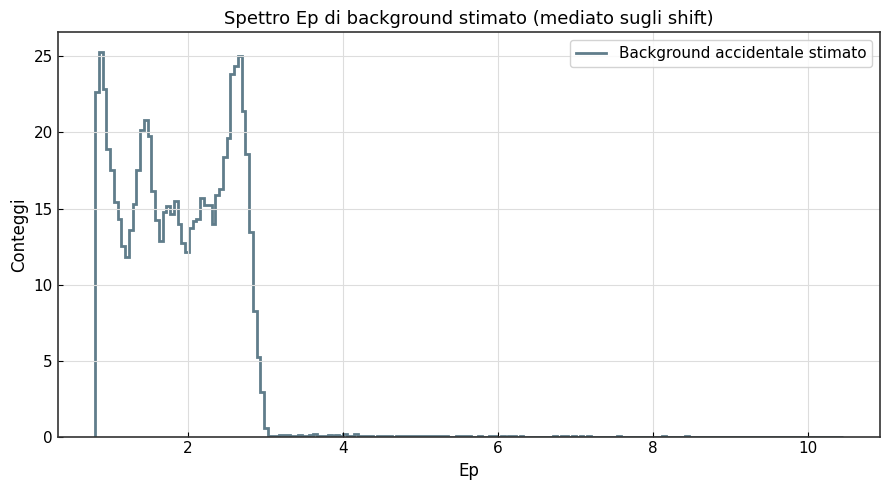

In [30]:
# Binning condiviso con gli spettri di segnale
bins_ep = np.linspace(
    float(min(Ep_true_signal.min(), Ep_selected.min())),
    float(max(Ep_true_signal.max(), Ep_selected.max())),
    200,
)

norm_factor = 0.2   

histo_background = estimate_background_spectrum(
    bg_dfs,
    bg_selected_masks,
    bins=bins_ep,
    energy_col="Ep",
    norm_factor=norm_factor,
)

print(f"Background stimato da {len(shifts_used)} shift")
print(f"Conteggi totali di background stimati: {histo_background.sum():.1f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.stairs(histo_background, bins_ep, color="#607D8B", linewidth=2,
          label="Background accidentale stimato")
ax.set_xlabel("Ep")
ax.set_ylabel("Conteggi")
ax.set_title("Spettro Ep di background stimato (mediato sugli shift)")
ax.legend()
plt.tight_layout()
plt.show()

### 10.4 — Spettro Ep con background sottratto

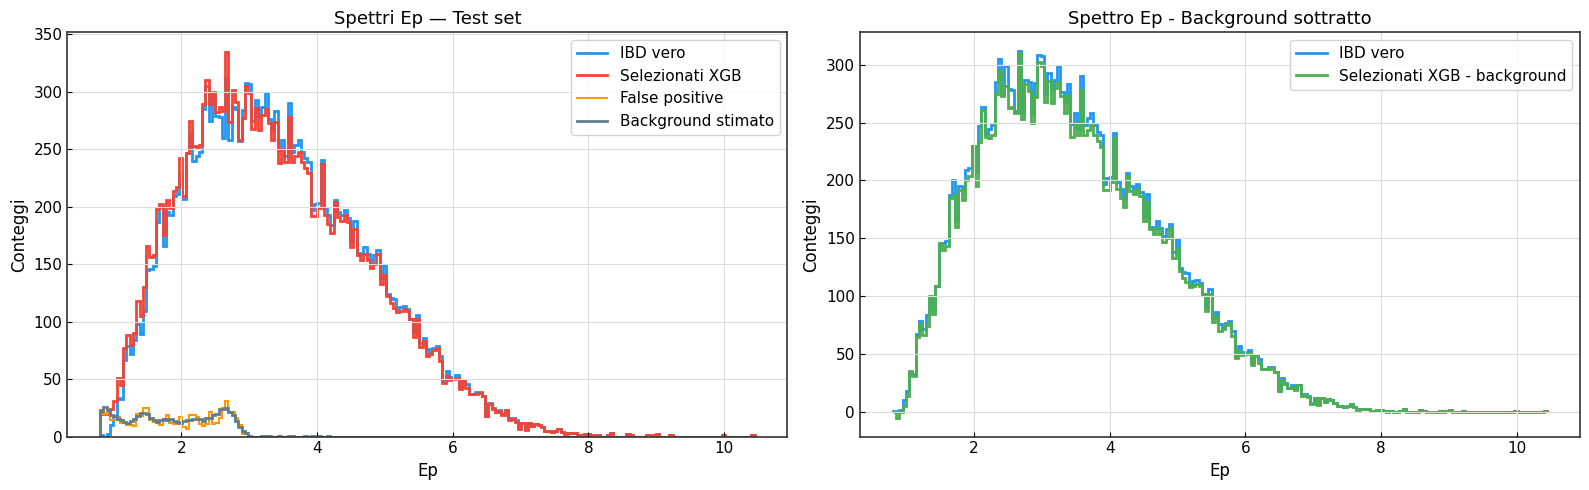

In [31]:
# Istogrammi nella regione di segnale, sullo STESSO binning
histo_truth,    _ = np.histogram(Ep_true_signal, bins=bins_ep)  # IBD vero
histo_selected, _ = np.histogram(Ep_selected,    bins=bins_ep)  # tutti i selezionati
histo_tp,       _ = np.histogram(Ep_tp,          bins=bins_ep)  # true positive
histo_fp,       _ = np.histogram(Ep_fp,          bins=bins_ep)  # false positive

histo_subtracted = histo_selected - histo_background

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pannello 1 — tutti gli spettri sovrapposti
ax = axes[0]
ax.stairs(histo_truth,      bins_ep, label="IBD vero",             color="#2196F3", linewidth=2)
ax.stairs(histo_selected,   bins_ep, label="Selezionati XGB",      color="#F44336", linewidth=2)
ax.stairs(histo_fp,         bins_ep, label="False positive",       color="#FF9800", linewidth=1.5)
ax.stairs(histo_background, bins_ep, label="Background stimato",   color="#607D8B", linewidth=2)
ax.set_xlabel("Ep")
ax.set_ylabel("Conteggi")
ax.set_title("Spettri Ep — Test set")
ax.legend()

# Pannello 2 — verità vs background sottratto
ax = axes[1]
ax.stairs(histo_truth,      bins_ep, label="IBD vero",                 color="#2196F3", linewidth=2)
ax.stairs(histo_subtracted, bins_ep, label="Selezionati XGB - background", color="#4CAF50", linewidth=2)
ax.set_xlabel("Ep")
ax.set_ylabel("Conteggi")
ax.set_title("Spettro Ep - Background sottratto")
ax.legend()

plt.tight_layout()

plt.show()

### 10.5 — Closure check

Quanto bene lo spettro con background sottratto recupera lo spettro IBD vero
(idealmente il rapporto è vicino a 1 su tutto l'intervallo di energia).

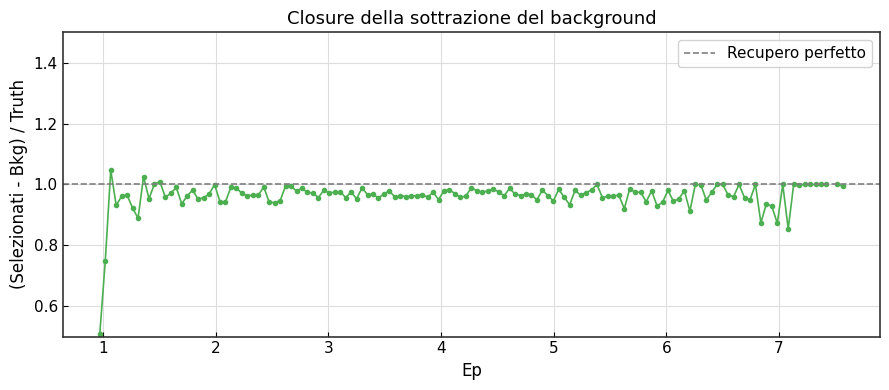

Integrale IBD vero          : 19989
Integrale sottratto         : 19346
Differenza relativa         : -3.22%


In [32]:
fig, ax = plt.subplots(figsize=(9, 4))

centers = 0.5 * (bins_ep[:-1] + bins_ep[1:])
ratio = histo_subtracted / (histo_truth + 1e-9)
ratio[histo_truth < 5] = np.nan   # ignora i bin a bassa statistica

ax.plot(centers, ratio, marker="o", markersize=3, color="#4CAF50", linewidth=1.2)
ax.axhline(1.0, linestyle="--", color="grey", linewidth=1.2, label="Recupero perfetto")
ax.set_xlabel("Ep")
ax.set_ylabel("(Selezionati - Bkg) / Truth")
ax.set_title("Closure della sottrazione del background")
ax.set_ylim([0.5, 1.5])
ax.legend()
plt.tight_layout()
plt.show()

# Confronto integrali
print(f"Integrale IBD vero          : {histo_truth.sum():.0f}")
print(f"Integrale sottratto         : {histo_subtracted.sum():.0f}")
print(f"Differenza relativa         : "
      f"{100*(histo_subtracted.sum() - histo_truth.sum())/histo_truth.sum():+.2f}%")

## 11 — Riepilogo finale

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_test, y_pred_test)
rec  = recall_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)

print("=" * 70)
print("  RIEPILOGO RISULTATI")
print("=" * 70)
print(f"  AUC test               : {auc_test:.4f}")
print(f"  AUC CV (media ± std)   : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  Soglia ottimale (F1)   : {best_thr:.4f}")
print(f"  Precision              : {prec:.4f}")
print(f"  Recall                 : {rec:.4f}")
print(f"  F1-score               : {f1:.4f}")
print(f"  Wasserstein (spectrum) : {wd:.6f}")
print(f"  N estimators (da CV)   : {n_est_optimal}")
print(f"  N eventi selezionati   : {selected_mask.sum()} / {len(y_test)}")
print("=" * 70)
print("\n  Iperparametri ottimali:")
print("-" * 40)
for k, v in best_params.items():
    print(f"    {k:22s}: {v}")
print("=" * 70)


  RIEPILOGO RISULTATI
  AUC test               : 0.9953
  AUC CV (media ± std)   : 0.9957 ± 0.0001
  Soglia ottimale (F1)   : 0.4774
  Precision              : 0.9664
  Recall                 : 0.9706
  F1-score               : 0.9685
  Wasserstein (spectrum) : 0.056630
  N estimators (da CV)   : 283
  N eventi selezionati   : 20076 / 39978

  Iperparametri ottimali:
----------------------------------------
    n_estimators          : 285
    max_depth             : 4
    learning_rate         : 0.057741724497710506
    subsample             : 0.6810710035492699
    colsample_bytree      : 0.6335240587459595
    min_child_weight      : 16
    reg_lambda            : 3.341524807896637
    reg_alpha             : 1.4132339105932177


## 12 - Stima errore

In [34]:
import numpy as np
import xgboost as xgb
import pickle

N_BOOTSTRAP = 500
bootstrap_predictions = []
for seed in range(N_BOOTSTRAP):
    print(f"Bootstrap model {seed+1}/{N_BOOTSTRAP}")
    rng = np.random.RandomState(seed)

    idx = rng.choice(len(X_train_full_sc), size=len(X_train_full_sc), replace=True)
    X_boot = X_train_full_sc.iloc[idx]
    y_boot = y_train_full.iloc[idx]

    model_boot = xgb.XGBClassifier(**best_params, random_state=seed, n_jobs=-1)
    model_boot.fit(X_boot,y_boot)
    pred = model_boot.predict_proba(X_test_sc)[:,1]
    bootstrap_predictions.append(pred)

bootstrap_predictions = np.array(bootstrap_predictions)
xgb_score_mean = bootstrap_predictions.mean(axis=0)
xgb_score_sigma = bootstrap_predictions.std(axis=0)

print("Mean model uncertainty:", xgb_score_sigma.mean())

np.save("xgb_score_sigma.npy", xgb_score_sigma)
np.save("xgb_score_mean.npy",xgb_score_mean)


Bootstrap model 1/500
Bootstrap model 2/500
Bootstrap model 3/500
Bootstrap model 4/500
Bootstrap model 5/500
Bootstrap model 6/500
Bootstrap model 7/500
Bootstrap model 8/500
Bootstrap model 9/500
Bootstrap model 10/500
Bootstrap model 11/500
Bootstrap model 12/500
Bootstrap model 13/500
Bootstrap model 14/500
Bootstrap model 15/500
Bootstrap model 16/500
Bootstrap model 17/500
Bootstrap model 18/500
Bootstrap model 19/500
Bootstrap model 20/500
Bootstrap model 21/500
Bootstrap model 22/500
Bootstrap model 23/500
Bootstrap model 24/500
Bootstrap model 25/500
Bootstrap model 26/500
Bootstrap model 27/500
Bootstrap model 28/500
Bootstrap model 29/500
Bootstrap model 30/500
Bootstrap model 31/500
Bootstrap model 32/500
Bootstrap model 33/500
Bootstrap model 34/500
Bootstrap model 35/500
Bootstrap model 36/500
Bootstrap model 37/500
Bootstrap model 38/500
Bootstrap model 39/500
Bootstrap model 40/500
Bootstrap model 41/500
Bootstrap model 42/500
Bootstrap model 43/500
Bootstrap model 44/5

## 13 - Bias

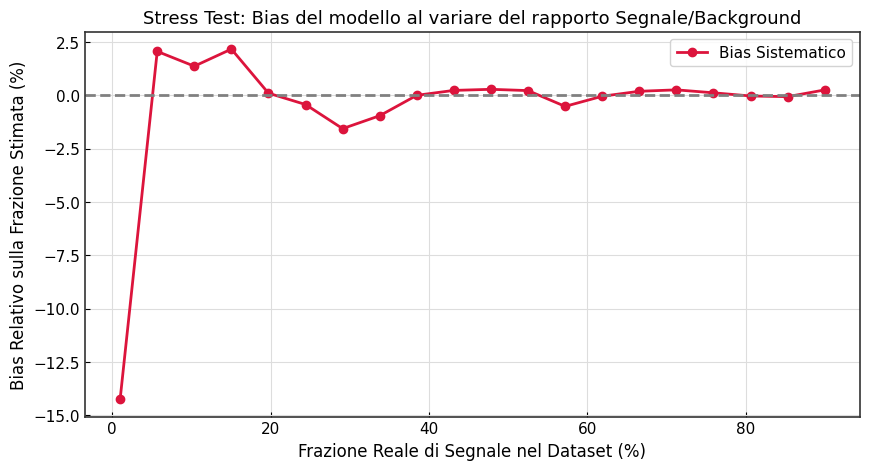

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Separizziamo segnale e background reali nel test set
df_test_sc = pd.DataFrame(X_test_sc)
df_test_sc['target'] = y_test.values

signal_test = df_test_sc[df_test_sc['target'] == 1]
bkg_test = df_test_sc[df_test_sc['target'] == 0]

# Generiamo le probabilità predette dal modello finale per i singoli gruppi
pred_signal = model.predict_proba(signal_test.drop(columns=['target']))[:, 1]
pred_bkg = model.predict_proba(bkg_test.drop(columns=['target']))[:, 1]

# Definiamo un range di frazioni di segnale reali da testare (es. da 1% a 90%)
true_signal_fractions = np.linspace(0.01, 0.90, 20)
soglia_taglio = 0.5 

bias_results = []
estimated_fractions = []

# Numero di eventi totali fissi da campionare ogni volta per non avere score alterati dalla statistica
N_tot = 10000 

for f_true in true_signal_fractions:
    # Calcoliamo quanti eventi di segnale e bkg campionare
    n_sig = int(N_tot * f_true)
    n_bkg = N_tot - n_sig
    
    # Campionamento con rimpiazzo (Bootstrap controllato sul rapporto S/B)
    idx_sig = np.random.choice(len(pred_signal), size=n_sig, replace=True)
    idx_bkg = np.random.choice(len(pred_bkg), size=n_bkg, replace=True)
    
    # Uniamo i punteggi predetti
    sample_preds = np.concatenate([pred_signal[idx_sig], pred_bkg[idx_bkg]])
    sample_truth = np.concatenate([np.ones(n_sig), np.zeros(n_bkg)])
    
    # Applichiamo il taglio di selezione
    selected_indices = sample_preds >= soglia_taglio
    
    # Quanti eventi passano il taglio?
    N_selected = np.sum(selected_indices)
    
    # Stima del numero di eventi di segnale purificati usando l'efficienza (TPR) e la contaminazione (FPR)
    # TPR (True Positive Rate) e FPR (False Positive Rate) sulla soglia scelta
    tpr = np.mean(pred_signal >= soglia_taglio)
    fpr = np.mean(pred_bkg >= soglia_taglio)
    
    # Formula di scomposizione standard: N_sel = N_sig_true * tpr + N_bkg_true * fpr
    # Risolvendo rispetto a N_sig_stimato (assumendo di conoscere le performance nominali del modello):
    if (tpr - fpr) != 0:
        N_sig_est = (N_selected - N_tot * fpr) / (tpr - fpr)
    else:
        N_sig_est = 0
        
    f_est = N_sig_est / N_tot
    estimated_fractions.append(f_est)
    
    # Bias relativo: (Stimato - Vero) / Vero
    bias = (f_est - f_true) / f_true
    bias_results.append(bias)

# Visualizzazione del grafico del Bias
plt.figure(figsize=(10, 5))
plt.plot(true_signal_fractions * 100, np.array(bias_results) * 100, 'o-', color='crimson', label='Bias Sistematico')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Frazione Reale di Segnale nel Dataset (%)")
plt.ylabel("Bias Relativo sulla Frazione Stimata (%)")
plt.title("Stress Test: Bias del modello al variare del rapporto Segnale/Background")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
import numpy as np
import pandas as pd

# 1. Separazione dei gruppi nel test set per lo stress test
df_test_sc = pd.DataFrame(X_test_sc)
df_test_sc['target'] = y_test.values

signal_test = df_test_sc[df_test_sc['target'] == 1].drop(columns=['target'])
bkg_test = df_test_sc[df_test_sc['target'] == 0].drop(columns=['target'])

# Probabilità predette dal modello finale
pred_signal = model.predict_proba(signal_test)[:, 1]
pred_bkg = model.predict_proba(bkg_test)[:, 1]

# Soglia nominale usata per la selezione
soglia_taglio = 0.5 

# Calcoliamo le efficienze nominali (True Positive Rate e False Positive Rate)
tpr_nominal = np.mean(pred_signal >= soglia_taglio)
fpr_nominal = np.mean(pred_bkg >= soglia_taglio)

# Testiamo uno spettro di frazioni reali di segnale (es. da 5% a 50%)
frazioni_test = np.linspace(0.05, 0.50, 10)
N_tot = 5000
max_relative_bias = 0.0

for f_true in frazioni_test:
    n_sig = int(N_tot * f_true)
    n_bkg = N_tot - n_sig
    
    # Campionamento
    idx_sig = np.random.choice(len(pred_signal), size=n_sig, replace=True)
    idx_bkg = np.random.choice(len(pred_bkg), size=n_bkg, replace=True)
    preds = np.concatenate([pred_signal[idx_sig], pred_bkg[idx_bkg]])
    
    # Eventi che superano il taglio
    n_selected = np.sum(preds >= soglia_taglio)
    
    # Ricostruzione della frazione stimata usando le efficienze nominali
    if (tpr_nominal - fpr_nominal) != 0:
        f_est = ((n_selected / N_tot) - fpr_nominal) / (tpr_nominal - fpr_nominal)
    else:
        f_est = f_true
        
    # Calcolo del bias relativo assoluto
    bias_rel = abs(f_est - f_true) / f_true
    if bias_rel > max_relative_bias:
        max_relative_bias = bias_rel

print(f"Massimo Bias Relativo Sistematico riscontrato: {max_relative_bias * 100:.2f}%")

# Salviamo l'incertezza sistematica relativa (es. 0.03 se è il 3%)
sys_error_fraction = np.array([max_relative_bias])
np.save("xgb_systematic_sb_bias.npy", sys_error_fraction)
print("File 'xgb_systematic_sb_bias.npy' salvato con successo.")

Massimo Bias Relativo Sistematico riscontrato: 3.98%
File 'xgb_systematic_sb_bias.npy' salvato con successo.
